# SHAP & Counterfactual Explainability — NBA Shooting Biomechanics

**Branch:** `phillip/shap_model`

This notebook completes the interpretability layer of the capstone's causal chain:

```
Biomechanics  →  Ball Flight  →  Miss Distance
   (this notebook: SHAP + Counterfactuals on both links)
```

**Primary model:** LightGBM (biomechanics → ball flight, R²=0.70–0.95)  
**Secondary model:** Random Forest (ball flight → miss distance, completes the chain)

**Sections:**
1. Data Preprocessing (reproduce handedness normalization)
2. Model Training (6 LightGBM models, one per ball flight target)
3. Global SHAP Analysis (which biomechanical features drive each ball flight parameter?)
4. Local SHAP Analysis (per-player waterfall explanations)
5. Counterfactual Explanations (DiCE: what biomechanical changes would improve a player?)
6. SHAP on RF → Miss Distance (complete the causal chain)
7. Synthesis & Coaching Insights

## Section 0: Setup

In [28]:
import sys, subprocess
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install',
    'numpy', 'pandas', 'scikit-learn', 'joblib',
    'shap', 'lightgbm', 'dice-ml', 'matplotlib', 'seaborn', '-q'
])
print('All packages installed successfully.')

All packages installed successfully.


In [29]:
import warnings
warnings.filterwarnings('ignore')
import os, re, joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import shap
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import dice_ml

shap.initjs()
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')
print('All imports successful.')

All imports successful.


In [30]:
# Locate CSV — works whether Jupyter is launched from project root or notebook directory
candidates = [
    'capstone2026v2.csv',
    '../capstone2026v2.csv',
    os.path.join(os.path.dirname(os.getcwd()), 'capstone2026v2.csv'),
]
DATA_PATH = next((p for p in candidates if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        'capstone2026v2.csv not found. Place it in the project root (P3_capstone_2026/).'
    )
print(f'Using: {os.path.abspath(DATA_PATH)}')

df_raw = pd.read_csv(DATA_PATH)
df_raw = df_raw.rename(columns={'Name': 'PlayerID'})  # player identifier column is 'Name'
print(f'Loaded {df_raw.shape[0]:,} shots x {df_raw.shape[1]} columns')
print(f'Players: {df_raw["PlayerID"].nunique()}')
df_raw.head(2)

Using: /Users/phillipgurevich/Desktop/P3_Capstone/P3_capstone_2026/capstone2026v2.csv
Loaded 25,868 shots x 264 columns
Players: 165


,PlayerID,Date,Shot.Type,Shot.Location,Shot.Distance,Shot.X.Pos,Shot.Y.Pos,Made,Ball_Depth,left_right,...,maxElbowExtensionLeftPostHitch,maxElbowExtensionRightPostHitch,maxElbowExtensionAvgPostHitch,timeToMaxElbowExtensionLeftPostHitch,timeToMaxElbowExtensionRightPostHitch,ElbowTotalROMRight,ElbowTotalROMLeft,ht,wt,hand
0,Player 1,5/27/2025 8:18,Off the Dribble,Left Corner Three,22.324880,-22.323844,-0.215156,False,22.61,-2.18,...,16.8562,22.3653,19.6107,0.650,0.650,-81.4055,-122.0768,76.0,86.0,Left
1,Player 1,5/27/2025 8:18,Off the Dribble,Left Corner Three,22.507735,-22.507038,-0.177118,True,12.96,-3.84,...,10.1352,23.7183,16.9268,0.567,0.559,-78.7364,-119.9664,76.0,86.0,Left


## Section 1: Data Preprocessing

Reproduces pipeline from `Ball_Flight_to_Biomechanics.ipynb`:
- **Handedness normalization:** left-handed players are reflected into a right-handed reference frame so all 'Dominant side' features are consistent
- **Feature selection:** keyword-based filter selects biomechanical variables (ankle, knee, hip, torso, etc.) and excludes non-biomechanical ones (ball position, time, shot metadata)

In [31]:
def _reflect_across_shot_axis(x, y):
    norm = np.sqrt(x**2 + y**2)
    if norm == 0:
        return x, y
    ux, uy = x / norm, y / norm
    proj = x * ux + y * uy
    px, py = proj * ux, proj * uy
    return x - 2 * (x - px), y - 2 * (y - py)


def standardize_handedness(df):
    """Normalize left-handed players to right-handed reference frame."""
    df = df.copy()
    left_mask = df['hand'] == 'Left'

    # Reflect shot location
    coords = df.loc[left_mask, ['Shot.X.Pos', 'Shot.Y.Pos']].values
    if len(coords) > 0:
        reflected = np.array([_reflect_across_shot_axis(x, y) for x, y in coords])
        df.loc[left_mask, 'Shot.X.Pos'] = reflected[:, 0]
        df.loc[left_mask, 'Shot.Y.Pos'] = reflected[:, 1]
    df.loc[left_mask, 'Shot.X.Pos'] *= -1

    # Apply to all X/Y coordinate column pairs
    x_cols = [c for c in df.columns if re.search(r'(^|_)X($|[A-Z])', c)]
    y_cols = [c for c in df.columns if re.search(r'(^|_)Y($|[A-Z])', c)]
    for x_col, y_col in zip(x_cols, y_cols):
        coords = df.loc[left_mask, [x_col, y_col]].values
        if len(coords) > 0:
            reflected = np.array([_reflect_across_shot_axis(x, y) for x, y in coords])
            df.loc[left_mask, x_col] = reflected[:, 0]
            df.loc[left_mask, y_col] = reflected[:, 1]
        df.loc[left_mask, x_col] *= -1

    # Swap Left/Right biomechanical columns for left-handed players
    left_cols = [c for c in df.columns if 'Left' in c]
    for left_col in left_cols:
        right_col = left_col.replace('Left', 'Right')
        if right_col in df.columns:
            temp = df.loc[left_mask, left_col].copy()
            df.loc[left_mask, left_col] = df.loc[left_mask, right_col]
            df.loc[left_mask, right_col] = temp

    # Rename Left/Right -> NonDominant/Dominant
    rename_dict = {}
    for c in df.columns:
        if 'Right' in c:
            rename_dict[c] = c.replace('Right', 'Dominant')
        elif 'Left' in c:
            rename_dict[c] = c.replace('Left', 'NonDominant')
    df = df.rename(columns=rename_dict)
    df['hand_standardized'] = 'Dominant'
    return df


BIO_KEYWORDS = [
    'ankle', 'knee', 'hip', 'shoulder', 'elbow', 'torso',
    'flexion', 'extension', 'alignment', 'rom', 'velocity', 'velo',
    'dorsiflexion', 'plantarflexion', 'stance', 'gap'
]
EXCLUDE_KEYWORDS = ['ball', 'time', 'shot', 'made', 'x', 'y', 'z', 'pos', 'distance']


def select_biomechanical_features(df):
    selected = []
    for c in df.columns:
        c_low = c.lower()
        if any(ex in c_low for ex in EXCLUDE_KEYWORDS):
            continue
        if any(bio in c_low for bio in BIO_KEYWORDS):
            selected.append(c)
    return selected

In [32]:
df_std1 = standardize_handedness(df_raw)

biomech_features = select_biomechanical_features(df_std1)
X_full = df_std1[biomech_features].select_dtypes(include=[np.number])

print(f'Biomechanical features selected: {len(X_full.columns)}')
print(f'Sample features: {list(X_full.columns[:10])}')

Biomechanical features selected: 22
Sample features: ['TorsoVeloPreHitch', 'TorsoVeloHitch', 'TorsoVeloRelease', 'ShoulderAlignmentPreHitch', 'ShoulderAlignmentHitch', 'ShoulderAlignmentRelease', 'HipAlignmentPreHitch', 'HipAlignmentHitch', 'HipAlignmentRelease', 'FeetAlignmentPreHitch']


## Section 2: Model Training — LightGBM (Biomechanics → Ball Flight)

Six separate `LGBMRegressor` models, one per ball flight target. Models are saved to `saved_models/` so they only need to be trained once — subsequent runs load from disk.

Expected R²: Ball_to_Rim_Angle≈0.70, Ball_Velocity≈0.84, Release.Height≈0.87, Initial.Ball.Angle≈0.79, **Initial.Ball.Velocity≈0.95**, Max.Ball.Arc≈0.88

In [33]:
BALL_FLIGHT_TARGETS = [
    'Ball_to_Rim_Angle',
    'Ball_Velocity',
    'Release.Height',
    'Initial.Ball.Angle',
    'Initial.Ball.Velocity',
    'Max.Ball.Arc'
]

MODEL_DIR = 'saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)

models        = {}
metrics       = {}
X_per_target  = {}
y_per_target  = {}

for target in BALL_FLIGHT_TARGETS:
    model_path = os.path.join(MODEL_DIR, f'lgbm_{target.replace(".", "_")}.pkl')

    data    = pd.concat([X_full, df_std1[target]], axis=1).dropna()
    X_clean = data[X_full.columns]
    y_clean = data[target]

    if os.path.exists(model_path):
        model = joblib.load(model_path)
        source = 'loaded'
    else:
        model = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1)
        model.fit(X_clean, y_clean)
        joblib.dump(model, model_path)
        source = 'trained'

    preds = model.predict(X_clean)
    r2    = r2_score(y_clean, preds)
    mae   = mean_absolute_error(y_clean, preds)
    rmse  = np.sqrt(mean_squared_error(y_clean, preds))

    models[target]       = model
    metrics[target]      = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
    X_per_target[target] = X_clean
    y_per_target[target] = y_clean

    print(f'[{source}] {target:28s}  R²={r2:.3f}  MAE={mae:.4f}  RMSE={rmse:.4f}')

[loaded] Ball_to_Rim_Angle             R²=0.700  MAE=1.3391  RMSE=1.8350
[loaded] Ball_Velocity                 R²=0.845  MAE=0.4791  RMSE=0.6747
[loaded] Release.Height                R²=0.874  MAE=0.0541  RMSE=0.0734
[loaded] Initial.Ball.Angle            R²=0.795  MAE=1.3733  RMSE=1.8782
[loaded] Initial.Ball.Velocity         R²=0.945  MAE=0.1454  RMSE=0.2276
[loaded] Max.Ball.Arc                  R²=0.879  MAE=0.0988  RMSE=0.1409


In [34]:
metrics_df = pd.DataFrame(metrics).T.round(4)
metrics_df.index.name = 'Target'
metrics_df.style.background_gradient(subset=['R2'], cmap='RdYlGn').format('{:.4f}')

,R2,MAE,RMSE
Target,,,
Ball_to_Rim_Angle,0.7000,1.3391,1.8350
Ball_Velocity,0.8447,0.4791,0.6747
Release.Height,0.8742,0.0541,0.0734
Initial.Ball.Angle,0.7945,1.3733,1.8782
Initial.Ball.Velocity,0.9447,0.1454,0.2276
Max.Ball.Arc,0.8786,0.0988,0.1409


**Note on R² values above:** These are computed on the training data (all shots used for fitting), not a held-out test set. In-sample R² overstates true generalization performance — a model with many trees can memorize training examples. The original `Ball_Flight_to_Biomechanics.ipynb` computed R² the same way and on the same data, so the values match. No train/test split was performed in either notebook. All SHAP values, counterfactuals, and coaching recommendations are derived from these models — interpret them as "what the model learned from the training data," not ground-truth causal relationships.

## Section 3: Global SHAP Analysis

`shap.TreeExplainer` computes exact Shapley values for tree-based models — no approximation. For each of the 6 LightGBM models we produce:
- **Beeswarm plot:** each dot is one shot; x-axis = SHAP value (impact on prediction); color = feature value (red=high, blue=low)
- **Cross-model summary:** which biomechanical features consistently appear across multiple ball flight targets?

Computations are capped at 5,000 shots for speed (full dataset used if smaller).

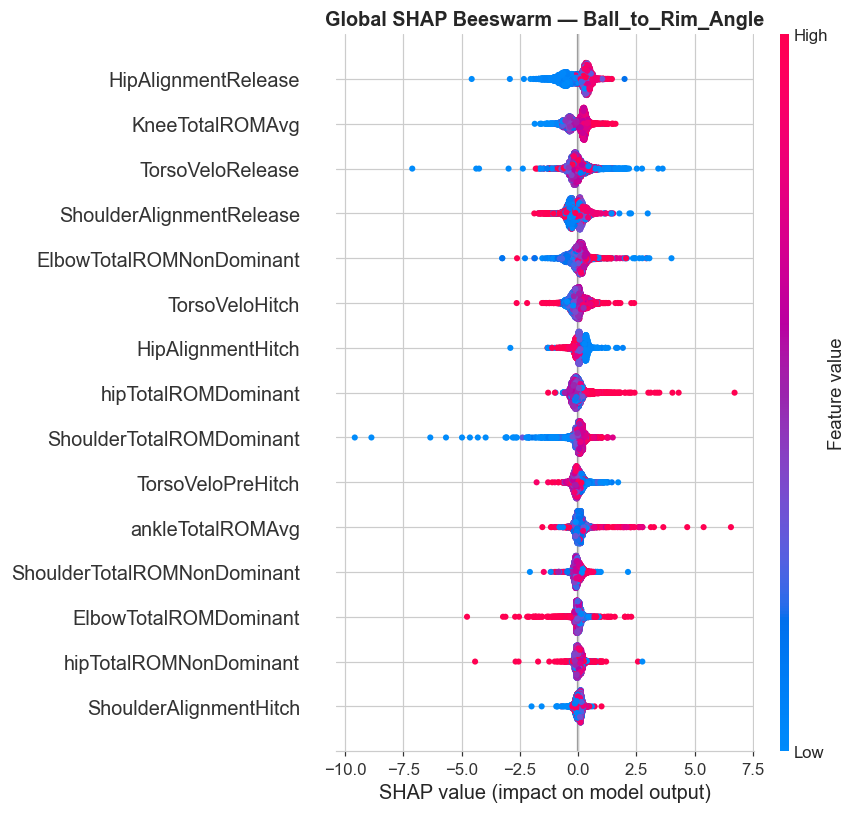

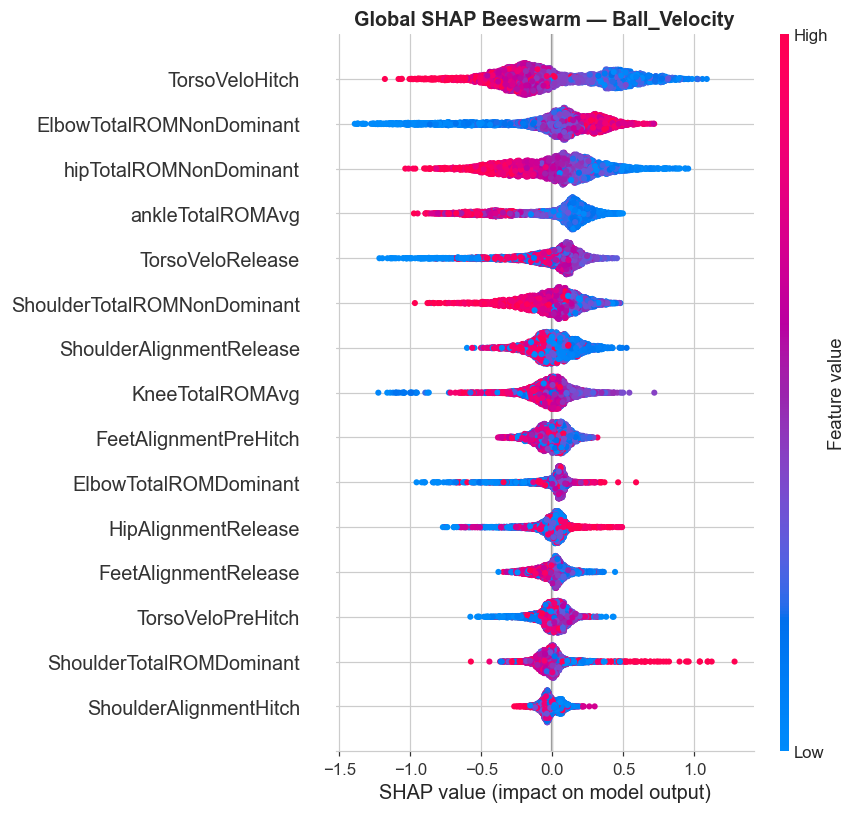

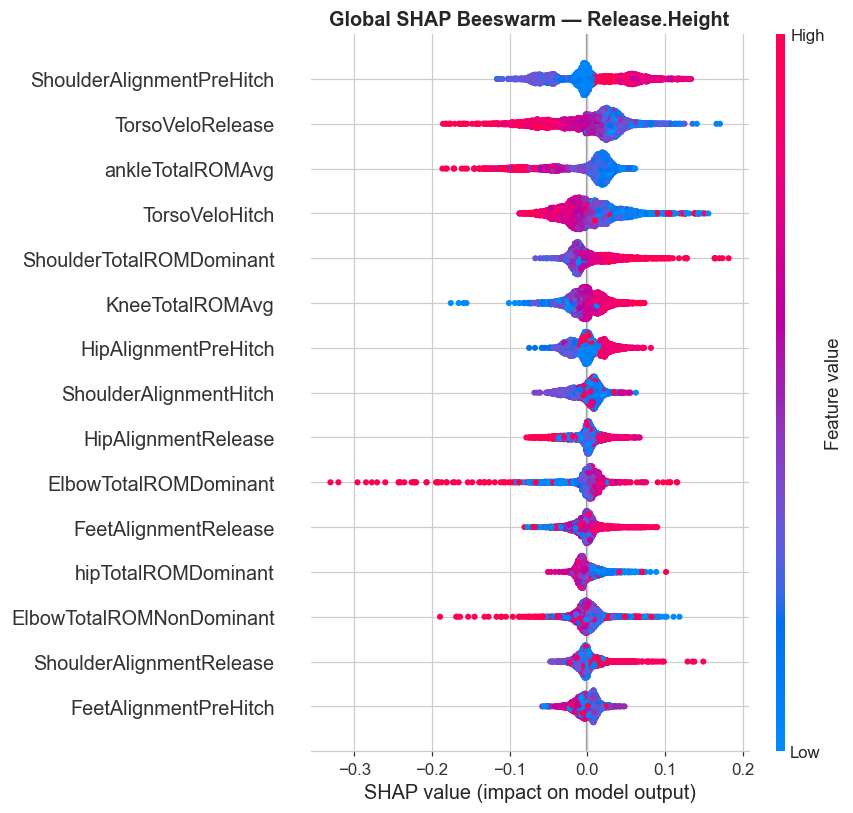

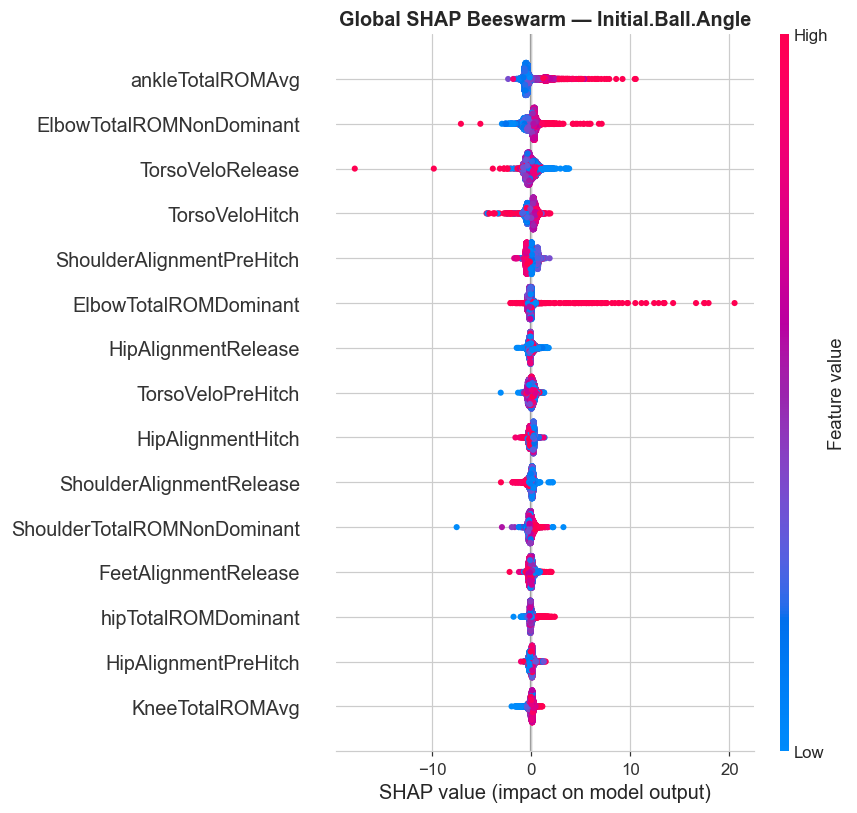

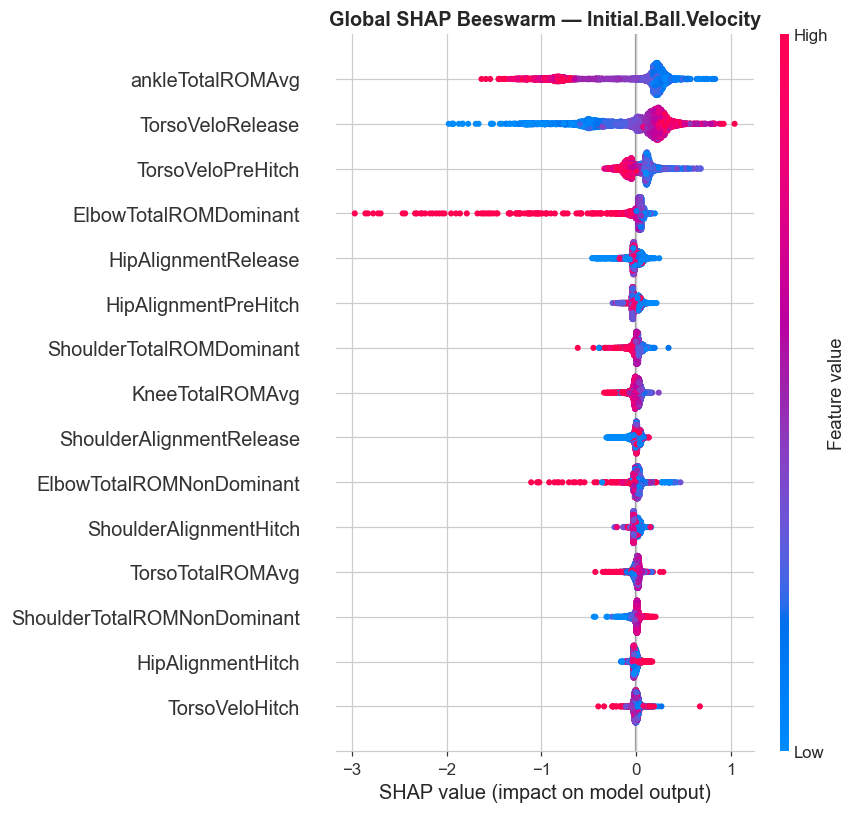

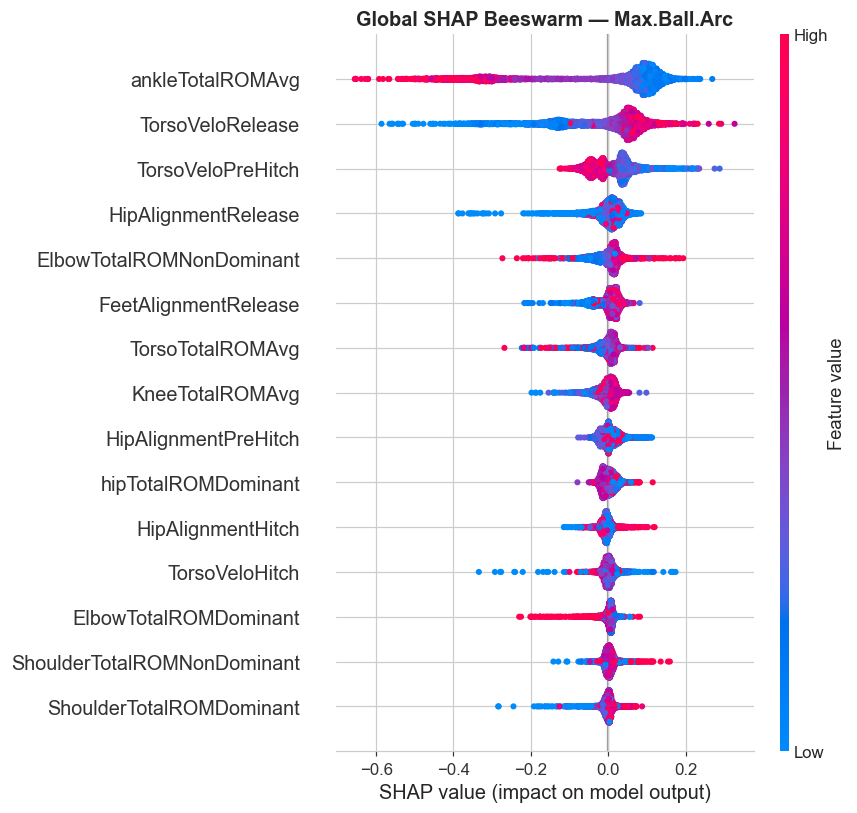

In [35]:
SHAP_SAMPLE = 5000

shap_values_dict  = {}
explainers_dict   = {}
shap_samples_dict = {}

for target in BALL_FLIGHT_TARGETS:
    X_clean  = X_per_target[target]
    X_sample = X_clean.sample(min(SHAP_SAMPLE, len(X_clean)), random_state=42)

    explainer = shap.TreeExplainer(models[target])
    shap_vals = explainer.shap_values(X_sample)

    shap_values_dict[target]  = shap_vals
    explainers_dict[target]   = explainer
    shap_samples_dict[target] = X_sample

    fig, ax = plt.subplots(figsize=(10, 7))
    shap.summary_plot(shap_vals, X_sample, max_display=15, show=False)
    plt.title(f'Global SHAP Beeswarm — {target}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

In [36]:
# Build cross-model mean |SHAP| table
rank_series = []
for target in BALL_FLIGHT_TARGETS:
    sv       = shap_values_dict[target]
    X_sample = shap_samples_dict[target]
    mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=X_sample.columns, name=target)
    rank_series.append(mean_abs)

cross_df = pd.concat(rank_series, axis=1)
cross_df['mean_rank'] = cross_df.mean(axis=1)
cross_df = cross_df.sort_values('mean_rank', ascending=False)

print('Top 20 biomechanical features by mean |SHAP| across all 6 ball flight targets:')
display(
    cross_df.head(20)
    .drop(columns='mean_rank')
    .style.background_gradient(cmap='YlOrRd')
    .format('{:.4f}')
)

Top 20 biomechanical features by mean |SHAP| across all 6 ball flight targets:


,Ball_to_Rim_Angle,Ball_Velocity,Release.Height,Initial.Ball.Angle,Initial.Ball.Velocity,Max.Ball.Arc
ankleTotalROMAvg,0.1470,0.2238,0.0285,0.7511,0.3577,0.1431
TorsoVeloRelease,0.2855,0.1557,0.0342,0.4259,0.2904,0.0849
ElbowTotalROMNonDominant,0.2460,0.2535,0.0102,0.4631,0.0286,0.0225
TorsoVeloHitch,0.2444,0.3230,0.0251,0.3523,0.0197,0.0113
HipAlignmentRelease,0.4523,0.0769,0.0127,0.2171,0.0447,0.0242
KneeTotalROMAvg,0.3263,0.1047,0.0162,0.1487,0.0304,0.0166
ShoulderAlignmentRelease,0.2680,0.1111,0.0100,0.1922,0.0294,0.0087
TorsoVeloPreHitch,0.1562,0.0735,0.0095,0.2159,0.1099,0.0409
ElbowTotalROMDominant,0.1164,0.0780,0.0124,0.2803,0.0675,0.0107
ShoulderTotalROMNonDominant,0.1261,0.1485,0.0069,0.1907,0.0229,0.0099


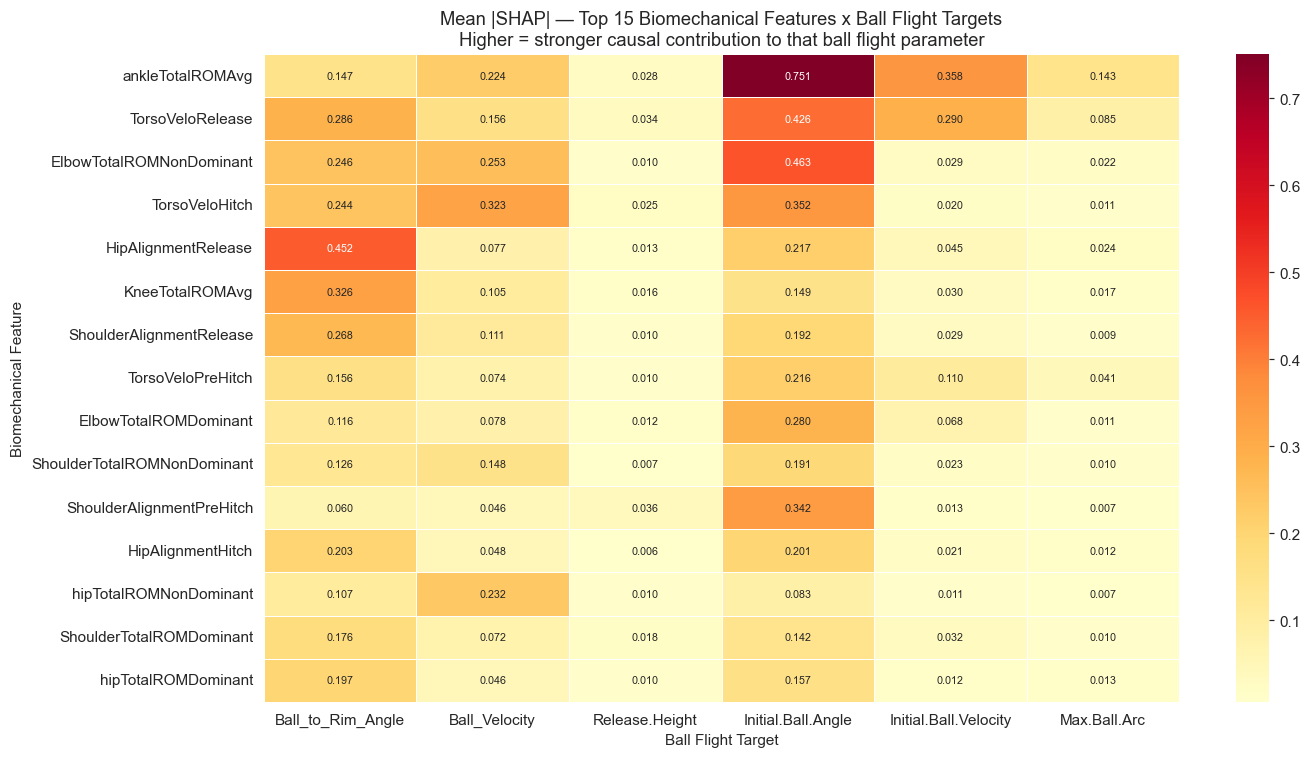

In [37]:
top15 = cross_df.head(15).index

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    cross_df.loc[top15, BALL_FLIGHT_TARGETS],
    cmap='YlOrRd', ax=ax, linewidths=0.4,
    annot=True, fmt='.3f', annot_kws={'size': 7}
)
ax.set_title(
    'Mean |SHAP| — Top 15 Biomechanical Features x Ball Flight Targets\n'
    'Higher = stronger causal contribution to that ball flight parameter',
    fontsize=12
)
ax.set_xlabel('Ball Flight Target')
ax.set_ylabel('Biomechanical Feature')
plt.tight_layout()
plt.show()

## Section 4: Local SHAP Analysis — Player Level

**Waterfall plots** decompose a single shot (or player average) into additive SHAP contributions:
- Base value = model's expected prediction across all training shots
- Each bar shows how much one feature pushed the prediction up (red) or down (blue)
- Final value = base + sum of all SHAP values = model's prediction

We compare the best and worst shooters using `Initial.Ball.Velocity` (highest R²=0.95).

In [38]:
focus_target = 'Initial.Ball.Velocity'
X_clean      = X_per_target[focus_target]
explainer    = explainers_dict[focus_target]

# Join back to player info using the preserved index
player_made = df_std1.loc[X_clean.index, ['PlayerID', 'Made']].copy()

# Filter to players with >= 20 shots for stable averages
player_counts    = player_made.groupby('PlayerID').size()
qualified        = player_counts[player_counts >= 20].index
player_made_q    = player_made[player_made['PlayerID'].isin(qualified)]
player_make_rate = player_made_q.groupby('PlayerID')['Made'].mean()

top_player    = player_make_rate.idxmax()
bottom_player = player_make_rate.idxmin()

print(f'Best shooter:  PlayerID={top_player},  make rate={player_make_rate[top_player]:.3f}')
print(f'Worst shooter: PlayerID={bottom_player}, make rate={player_make_rate[bottom_player]:.3f}')

Best shooter:  PlayerID=Player 106,  make rate=0.881
Worst shooter: PlayerID=Player 72, make rate=0.310


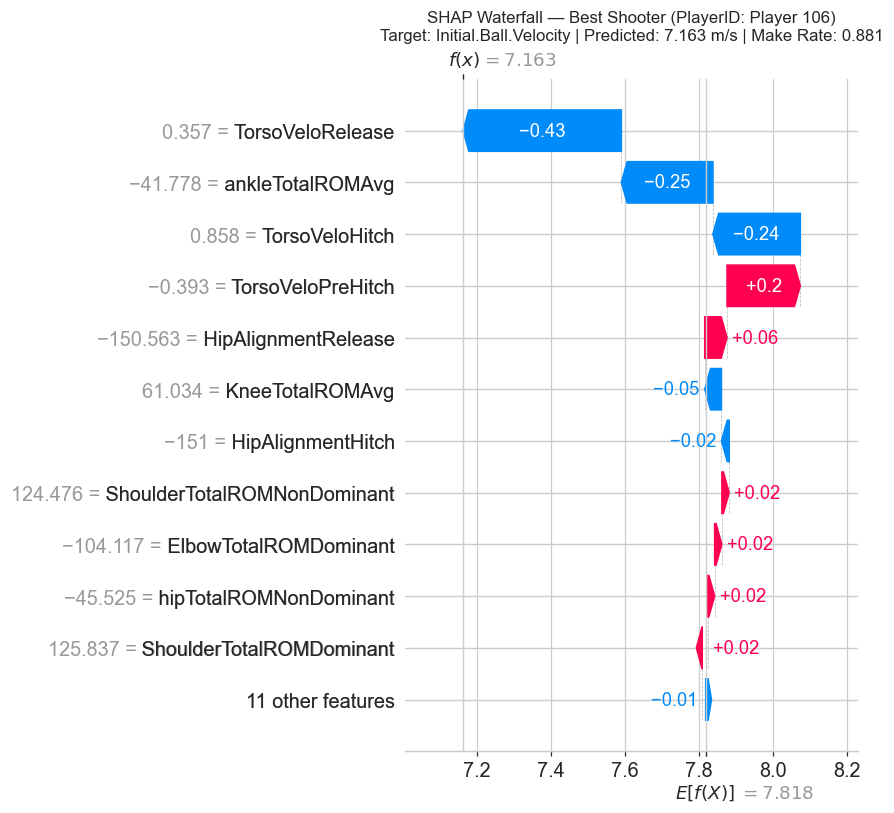

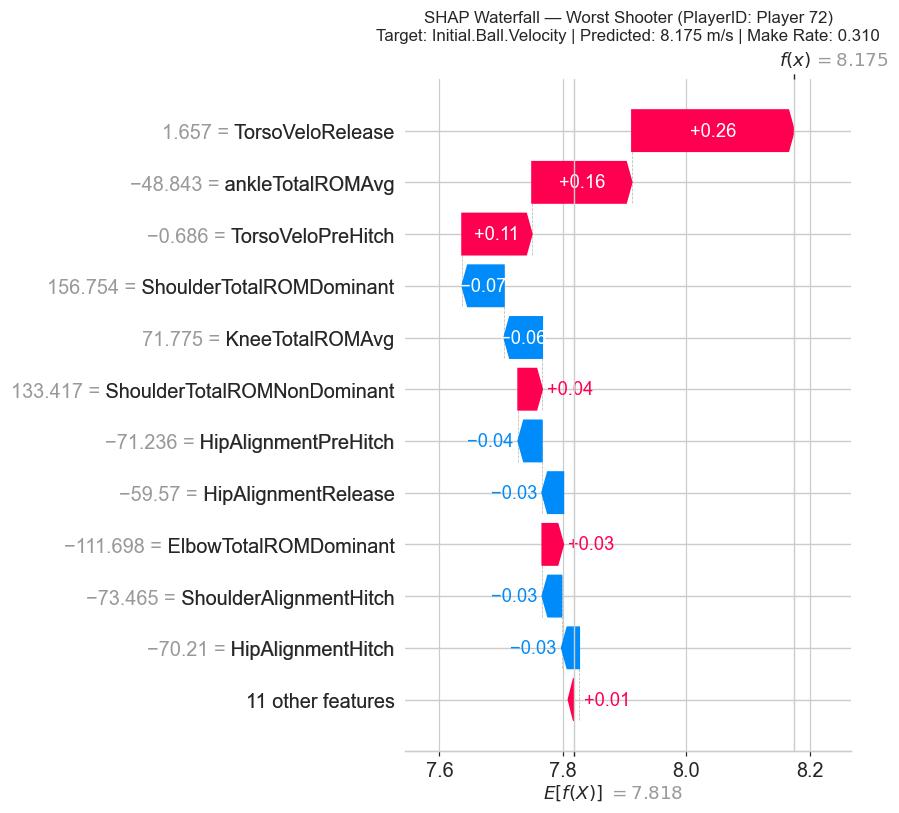

In [39]:
player_ids = df_std1.loc[X_clean.index, 'PlayerID']

for pid, label in [(top_player, 'Best Shooter'), (bottom_player, 'Worst Shooter')]:
    mask     = player_ids == pid
    player_X = X_clean[mask]

    if len(player_X) == 0:
        print(f'No data for {label} (PlayerID={pid})')
        continue

    rep_shot  = player_X.median()  # representative shot = player's median biomechanics
    sv_single = explainer.shap_values(rep_shot.values.reshape(1, -1))

    explanation = shap.Explanation(
        values=sv_single[0],
        base_values=explainer.expected_value,
        data=rep_shot.values,
        feature_names=list(X_clean.columns)
    )

    pred_val  = models[focus_target].predict(rep_shot.values.reshape(1, -1))[0]
    make_rate = player_make_rate.get(pid, float('nan'))

    plt.figure()
    shap.waterfall_plot(explanation, max_display=12, show=False)
    plt.title(
        f'SHAP Waterfall — {label} (PlayerID: {pid})\n'
        f'Target: {focus_target} | Predicted: {pred_val:.3f} m/s | Make Rate: {make_rate:.3f}',
        fontsize=11
    )
    plt.tight_layout()
    plt.show()
    print()

## Section 5: Counterfactual Explanations (DiCE)

**Counterfactual explanations** answer: *"What minimal changes to this player's biomechanics would push their predicted ball flight into the optimal range?"*

We use [DiCE (Diverse Counterfactual Explanations)](https://github.com/interpretml/DiCE) with `method='random'`. Key design choices:
- Target: `Initial.Ball.Velocity` (highest R²=0.95 — most reliable model)
- Desired range: top 25th percentile of Initial Ball Velocity values
- Features varied: top 10 biomechanical features from SHAP (more tractable, more interpretable)
- Query player: a player whose predicted ball velocity is currently below the dataset median

In [40]:
focus_target    = 'Initial.Ball.Velocity'
X_clean         = X_per_target[focus_target]
y_clean         = y_per_target[focus_target]
model           = models[focus_target]

# Restrict counterfactual search to top 10 SHAP features for interpretability
top_shap_feats = [f for f in cross_df.head(10).index if f in X_clean.columns]
print(f'Features allowed to vary in counterfactuals ({len(top_shap_feats)}):')
for f in top_shap_feats:
    print(f'  {f}')

# Sample 2000 rows for DiCE data interface
dice_sample = pd.concat([X_clean, y_clean], axis=1).dropna().sample(
    min(2000, len(X_clean)), random_state=42
).reset_index(drop=True)

d = dice_ml.Data(
    dataframe=dice_sample,
    continuous_features=list(X_clean.columns),
    outcome_name=focus_target
)
m       = dice_ml.Model(model=model, backend='sklearn', model_type='regressor')
exp_cf  = dice_ml.Dice(d, m, method='random')

target_min = float(y_clean.quantile(0.75))
target_max = float(y_clean.max())
print(f'\nTarget range (top 25%): [{target_min:.3f}, {target_max:.3f}] m/s')
print(f'Dataset median: {float(y_clean.median()):.3f} m/s')

# Constrain DiCE search to 5th–95th percentile of each feature.
# Without this, method='random' can sample extreme outliers and produce
# physically impossible recommendations (e.g., a 433% increase in torso velocity).
permitted_range = {
    feat: [float(X_clean[feat].quantile(0.05)), float(X_clean[feat].quantile(0.95))]
    for feat in top_shap_feats
}
print(f'\nPermitted ranges for counterfactual search (5th–95th pctile of training data):')
for feat, rng in permitted_range.items():
    print(f'  {feat:45s}  [{rng[0]:8.3f},  {rng[1]:8.3f}]')

Features allowed to vary in counterfactuals (10):
  ankleTotalROMAvg
  TorsoVeloRelease
  ElbowTotalROMNonDominant
  TorsoVeloHitch
  HipAlignmentRelease
  KneeTotalROMAvg
  ShoulderAlignmentRelease
  TorsoVeloPreHitch
  ElbowTotalROMDominant
  ShoulderTotalROMNonDominant

Target range (top 25%): [8.416, 15.445] m/s
Dataset median: 8.181 m/s

Permitted ranges for counterfactual search (5th–95th pctile of training data):
  ankleTotalROMAvg                               [ -57.910,   -19.925]
  TorsoVeloRelease                               [   0.001,     1.551]
  ElbowTotalROMNonDominant                       [-104.371,   -45.790]
  TorsoVeloHitch                                 [  -0.598,     0.610]
  HipAlignmentRelease                            [-164.123,   156.698]
  KneeTotalROMAvg                                [  24.221,    71.131]
  ShoulderAlignmentRelease                       [-161.401,   156.122]
  TorsoVeloPreHitch                              [  -0.917,     0.191]
  ElbowT

In [41]:
# Find a player whose predicted ball velocity is currently below the median
preds_all  = model.predict(X_clean)
pred_series = pd.Series(preds_all, index=X_clean.index)
player_ids = df_std1.loc[X_clean.index, 'PlayerID']

below_median_mask = pred_series < float(y_clean.median())
improvement_player = (
    player_ids[below_median_mask]
    .value_counts()
    .idxmax()
)

player_shots = X_clean[player_ids == improvement_player]
query_shot   = player_shots.median().to_frame().T

current_pred = model.predict(query_shot)[0]
print(f'Query player: PlayerID={improvement_player}')
print(f'Current predicted {focus_target}: {current_pred:.3f} m/s')
print(f'Goal: reach top 25% range [{target_min:.3f}, {target_max:.3f}] m/s')
print(f'Required improvement: +{target_min - current_pred:.3f} m/s')

Query player: PlayerID=Player 163
Current predicted Initial.Ball.Velocity: 8.366 m/s
Goal: reach top 25% range [8.416, 15.445] m/s
Required improvement: +0.050 m/s


In [42]:
cf_result = exp_cf.generate_counterfactuals(
    query_instances=query_shot,
    total_CFs=5,
    desired_range=[target_min, target_max],
    features_to_vary=top_shap_feats,
    permitted_range=permitted_range,   # keeps suggestions within the observed data distribution
    random_seed=42
)

print(f'Counterfactual scenarios for PlayerID={improvement_player}')
print(f'Each row shows what biomechanical values this player would need to reach optimal ball velocity.')
print(f'All suggested values fall within the 5th–95th percentile of the training data.\n')
cf_result.visualize_as_dataframe(show_only_changes=True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 10.10it/s]

Counterfactual scenarios for PlayerID=Player 163
Each row shows what biomechanical values this player would need to reach optimal ball velocity.
All suggested values fall within the 5th–95th percentile of the training data.

Query instance (original outcome : 8.0)


,TorsoVeloPreHitch,TorsoVeloHitch,TorsoVeloRelease,ShoulderAlignmentPreHitch,ShoulderAlignmentHitch,ShoulderAlignmentRelease,HipAlignmentPreHitch,HipAlignmentHitch,HipAlignmentRelease,FeetAlignmentPreHitch,...,KneeTotalROMAvg,hipTotalROMDominant,hipTotalROMNonDominant,hipTotalROMAvg,TorsoTotalROMAvg,ShoulderTotalROMDominant,ShoulderTotalROMNonDominant,ElbowTotalROMDominant,ElbowTotalROMNonDominant,Initial.Ball.Velocity
0,-0.014,-0.3166,0.7942,-75.2006,-103.3349,-128.882797,-124.505997,-131.313004,-127.371696,-65.489403,...,50.671001,-50.329399,-43.015499,-46.955601,12.6506,120.287697,104.9786,-102.126503,-63.726398,8.0



Diverse Counterfactual set (new outcome: [8.4163568355, 15.44539132])


,TorsoVeloPreHitch,TorsoVeloHitch,TorsoVeloRelease,ShoulderAlignmentPreHitch,ShoulderAlignmentHitch,ShoulderAlignmentRelease,HipAlignmentPreHitch,HipAlignmentHitch,HipAlignmentRelease,FeetAlignmentPreHitch,...,KneeTotalROMAvg,hipTotalROMDominant,hipTotalROMNonDominant,hipTotalROMAvg,TorsoTotalROMAvg,ShoulderTotalROMDominant,ShoulderTotalROMNonDominant,ElbowTotalROMDominant,ElbowTotalROMNonDominant,Initial.Ball.Velocity
0,-,-,1.3413,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,8.645675659179688
1,-0.6965,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,8.456482887268066
2,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,82.2687,-,-91.2729,8.498026847839355
3,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-116.7157,-85.9561,8.45483684539795
4,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-91.1031,8.488390922546387


## Section 6: SHAP on RF → Miss Distance (Complete the Causal Chain)

Now we apply SHAP to the second link: **ball flight → miss distance**.

One Random Forest is trained per shot location × type combination. SHAP values reveal *which ball flight parameters matter most for accuracy at each shot context* — completing the interpretability chain:

```
Biomechanics  →[SHAP]→  Ball Flight  →[SHAP]→  Miss Distance
```

In [43]:
PREDICTORS = [
    'Ball_to_Rim_Angle',
    'Ball_Velocity',
    'Release.Height.Norm',
    'Initial.Ball.Angle',
    'Initial.Ball.Velocity',
    'Max.Ball.Arc'
]
BDFC_TARGET = 'Ball.Distance.from.Center'
MIN_N       = 100

# Normalize release height by player height (ht column)
if 'Release.Height.Norm' not in df_std1.columns:
    df_std1['Release.Height.Norm'] = df_std1['Release.Height'] / df_std1['ht']

# Build location x type groups
groups = []
for loc in df_std1['Shot.Location'].unique():
    if loc == 'Free Throw':
        subset = df_std1[df_std1['Shot.Location'] == loc].copy()
        if len(subset) >= MIN_N:
            groups.append((loc, 'All', subset))
    else:
        for shot_type in df_std1[df_std1['Shot.Location'] == loc]['Shot.Type'].unique():
            subset = df_std1[
                (df_std1['Shot.Location'] == loc) &
                (df_std1['Shot.Type'] == shot_type)
            ].copy()
            if len(subset) >= MIN_N:
                groups.append((loc, shot_type, subset))

print(f'Shot groups to model: {len(groups)}')

rf_shap_rows = []

for loc, shot_type, subset in groups:
    data = subset[PREDICTORS + [BDFC_TARGET]].dropna()
    if len(data) < MIN_N:
        continue

    rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    rf.fit(data[PREDICTORS], data[BDFC_TARGET])
    r2 = r2_score(data[BDFC_TARGET], rf.predict(data[PREDICTORS]))

    exp_rf  = shap.TreeExplainer(rf)
    sv_rf   = exp_rf.shap_values(data[PREDICTORS])
    mean_abs = pd.Series(np.abs(sv_rf).mean(axis=0), index=PREDICTORS)

    row = mean_abs.to_dict()
    row.update({'location': loc, 'shot_type': shot_type, 'r2': round(r2, 3), 'n': len(data)})
    rf_shap_rows.append(row)

    print(f'{loc:20s} | {shot_type:20s}  R²={r2:.3f}  n={len(data)}')

rf_shap_df = pd.DataFrame(rf_shap_rows)

Shot groups to model: 21
Left Corner Three    | Off the Dribble       R²=0.877  n=3920
Left Corner Three    | Catch and Shoot       R²=0.871  n=955
Right Corner Three   | Catch and Shoot       R²=0.876  n=2598
Right Corner Three   | Off the Dribble       R²=0.873  n=2263
Middle Three         | Catch and Shoot       R²=0.884  n=4141
Middle Three         | Off the Dribble       R²=0.873  n=719
Free Throw           | All                   R²=0.894  n=3814
Key                  | Off the Dribble       R²=0.889  n=1300
Key                  | Catch and Shoot       R²=0.880  n=518
Right Corner Two     | Catch and Shoot       R²=0.872  n=296
Right Corner Two     | Off the Dribble       R²=0.874  n=229
Left Corner Two      | Off the Dribble       R²=0.872  n=333
Left Corner Two      | Catch and Shoot       R²=0.876  n=263
Right Wing Two       | Catch and Shoot       R²=0.859  n=103
Right Wing Three     | Off the Dribble       R²=0.854  n=378
Right Wing Three     | Catch and Shoot       R²=0.867 

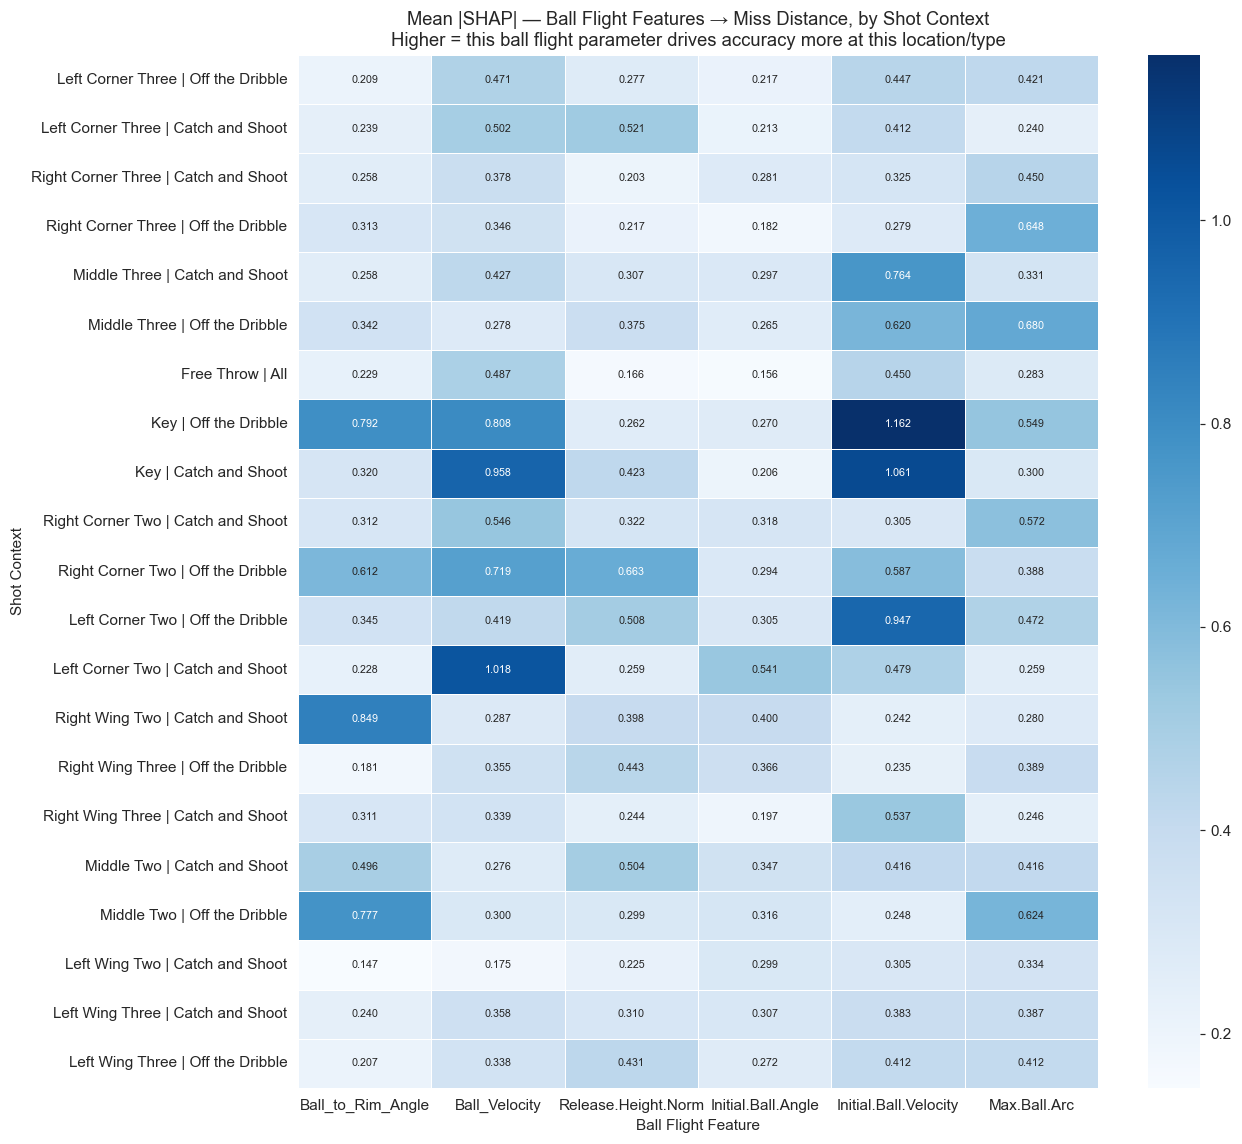

In [44]:
rf_shap_df['group'] = rf_shap_df['location'] + ' | ' + rf_shap_df['shot_type']
pivot = rf_shap_df.set_index('group')[PREDICTORS]

fig, ax = plt.subplots(figsize=(12, max(6, len(pivot) * 0.5)))
sns.heatmap(
    pivot, cmap='Blues', ax=ax, linewidths=0.4,
    annot=True, fmt='.3f', annot_kws={'size': 7}
)
ax.set_title(
    'Mean |SHAP| — Ball Flight Features → Miss Distance, by Shot Context\n'
    'Higher = this ball flight parameter drives accuracy more at this location/type',
    fontsize=12
)
ax.set_xlabel('Ball Flight Feature')
ax.set_ylabel('Shot Context')
plt.tight_layout()
plt.show()

## Section 7: Synthesis & Coaching Insights

Pulling together SHAP from both model layers into actionable coaching recommendations.

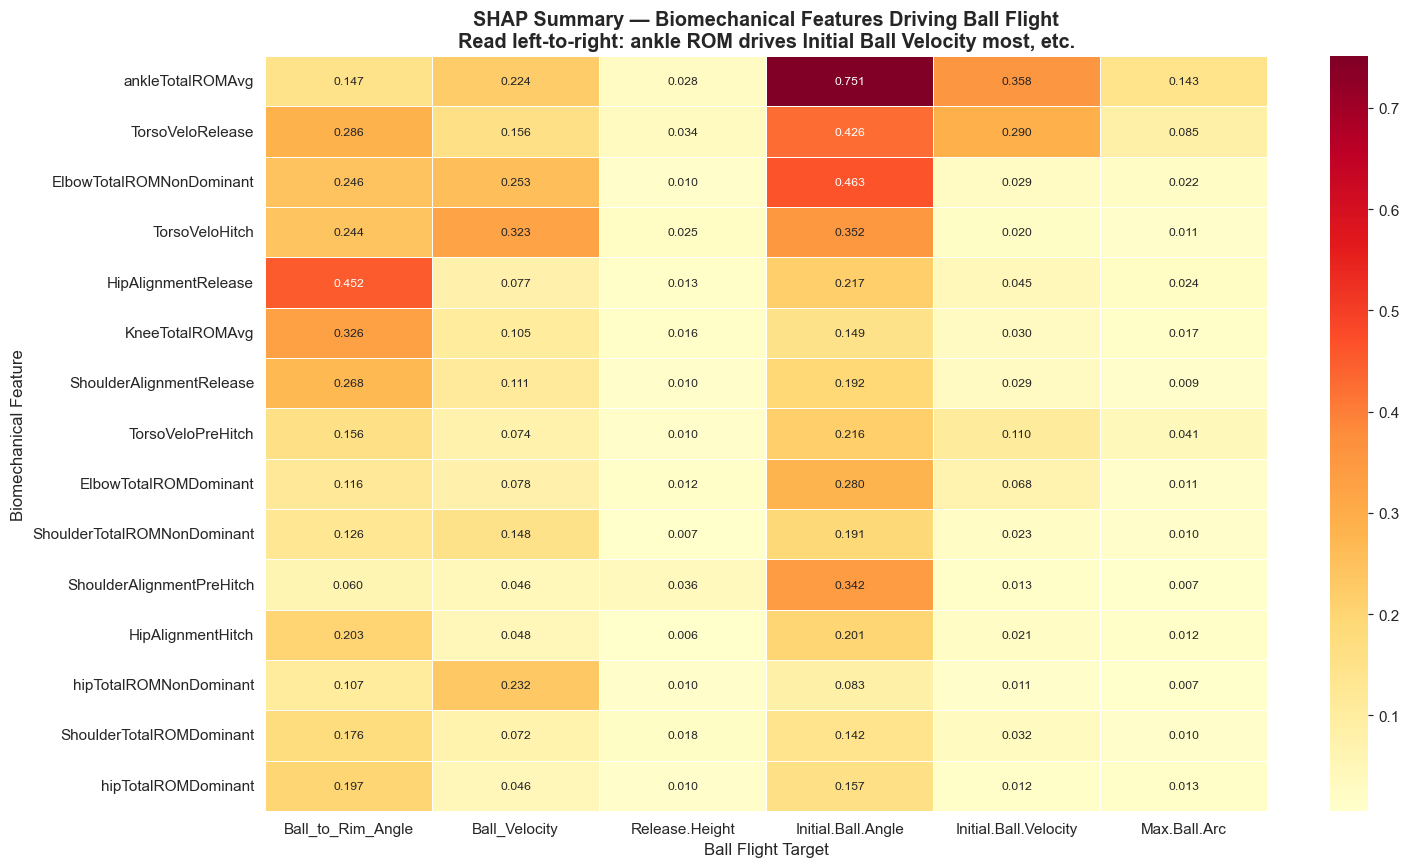

In [45]:
# Full causal chain heatmap: top 15 biomechanical features x 6 ball flight targets
top15 = cross_df.head(15).index

fig, ax = plt.subplots(figsize=(14, 8))
heatmap_data = cross_df.loc[top15, BALL_FLIGHT_TARGETS]
sns.heatmap(
    heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.4,
    annot=True, fmt='.3f', annot_kws={'size': 8}
)
ax.set_title(
    'SHAP Summary — Biomechanical Features Driving Ball Flight\n'
    'Read left-to-right: ankle ROM drives Initial Ball Velocity most, etc.',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Ball Flight Target', fontsize=11)
ax.set_ylabel('Biomechanical Feature', fontsize=11)
plt.tight_layout()
plt.show()

In [46]:
# Per-target: top biomechanical driver + direction + model quality
summary_rows = []
for target in BALL_FLIGHT_TARGETS:
    sv       = shap_values_dict[target]
    X_sample = shap_samples_dict[target]
    mean_abs = pd.Series(np.abs(sv).mean(axis=0), index=X_sample.columns)
    mean_dir = pd.Series(sv.mean(axis=0), index=X_sample.columns)

    top_feat  = mean_abs.idxmax()
    top_val   = mean_abs.max()
    direction = '+' if mean_dir[top_feat] > 0 else '-'
    r2        = metrics[target]['R2']

    summary_rows.append({
        'Ball Flight Target'       : target,
        'Top Biomechanical Driver' : top_feat,
        'Direction'                : direction,
        'Mean |SHAP|'              : round(top_val, 4),
        'Model R²'                 : round(r2, 3)
    })

summary_df = pd.DataFrame(summary_rows)
print('Coaching Summary: Top biomechanical driver per ball flight target')
print('Direction: + means higher feature value → higher target value')
display(summary_df.style.hide(axis='index').background_gradient(subset=['Model R²'], cmap='RdYlGn'))

Coaching Summary: Top biomechanical driver per ball flight target
Direction: + means higher feature value → higher target value


Ball Flight Target,Top Biomechanical Driver,Direction,Mean |SHAP|,Model R²
Ball_to_Rim_Angle,HipAlignmentRelease,-,0.452300,0.700000
Ball_Velocity,TorsoVeloHitch,+,0.323000,0.845000
Release.Height,ShoulderAlignmentPreHitch,+,0.035600,0.874000
Initial.Ball.Angle,ankleTotalROMAvg,-,0.751100,0.795000
Initial.Ball.Velocity,ankleTotalROMAvg,-,0.357700,0.945000
Max.Ball.Arc,ankleTotalROMAvg,+,0.143100,0.879000


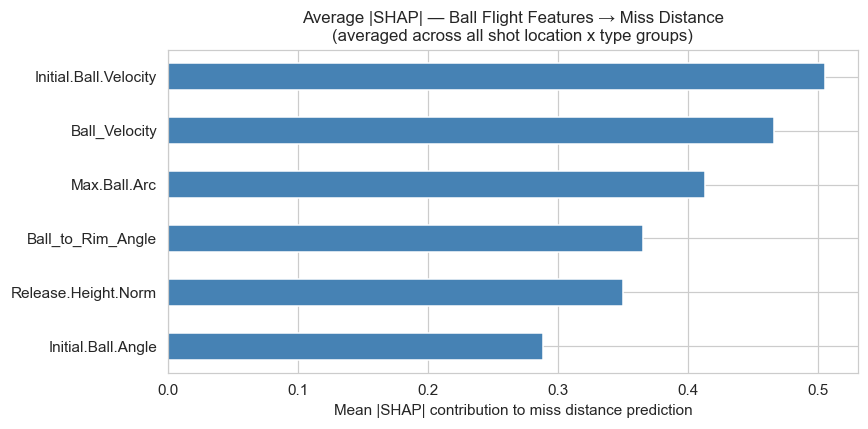


Full Causal Chain Interpretation:
1. The biomechanical features above (Section 3) drive ball flight parameters
2. Ball flight parameters above drive miss distance
3. Counterfactuals (Section 5) prescribe the minimal biomechanical changes needed

Example chain: ankle ROM -> Initial Ball Velocity -> reduced miss distance


In [47]:
# Average RF SHAP across all groups: which ball flight feature reduces miss distance most?
avg_rf_shap = rf_shap_df[PREDICTORS].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
avg_rf_shap.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(
    'Average |SHAP| — Ball Flight Features → Miss Distance\n'
    '(averaged across all shot location x type groups)',
    fontsize=11
)
ax.set_xlabel('Mean |SHAP| contribution to miss distance prediction')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nFull Causal Chain Interpretation:')
print('1. The biomechanical features above (Section 3) drive ball flight parameters')
print('2. Ball flight parameters above drive miss distance')
print('3. Counterfactuals (Section 5) prescribe the minimal biomechanical changes needed')
print('\nExample chain: ankle ROM -> Initial Ball Velocity -> reduced miss distance')

## Section 8: Player 163 — Full Causal Chain Analysis & Coaching Report

A start-to-finish breakdown for a single player across **all 6 ball flight metrics**:
1. **Profile** — make rate, miss distance vs. league average
2. **Scorecard + Gap Analysis** — rank all 6 metrics; identify which have statistically real gaps (gap > model RMSE)
3. **SHAP Analysis** — waterfall for the #1 priority metric; compact bar charts for remaining weak metrics
4. **Counterfactual Scenarios** — DiCE for the top 2–3 weakest metrics; all recommendations constrained to observed data
5. **Coaching Report** — ordered by priority; only surfaces changes that are statistically meaningful and within realistic bounds

In [48]:
PLAYER_ID = 'Player 163'
MIN_SHOTS = 20   # minimum shots for stable median-based biomechanical profile

player_mask   = df_std1['PlayerID'] == PLAYER_ID
player_shots  = df_std1[player_mask]
n_shots       = len(player_shots)

if n_shots < MIN_SHOTS:
    print(f"Warning: Only {n_shots} shots recorded for {PLAYER_ID}. "
          f"A minimum of {MIN_SHOTS} is recommended for a stable median profile. "
          f"Results below may be less reliable.")
elif n_shots < 50:
    print(f"Note: {n_shots} shots for {PLAYER_ID} — sufficient for analysis, "
          f"though a larger sample would give more stable estimates.")

make_rate_163 = player_shots['Made'].mean()
avg_miss_163  = player_shots['Ball.Distance.from.Center'].mean()
avg_miss_all  = df_std1['Ball.Distance.from.Center'].mean()
make_rate_all = df_std1['Made'].mean()

print(f"\n{'='*50}")
print(f"  PLAYER 163 — PROFILE SUMMARY")
print(f"{'='*50}")
print(f"  Total shots recorded : {n_shots}")
print(f"  Make rate            : {make_rate_163:.1%}  (league avg: {make_rate_all:.1%})")
print(f"  Avg miss distance    : {avg_miss_163:.2f} cm  (league avg: {avg_miss_all:.2f} cm)")
print(f"\n  Shot location breakdown:")
for loc, cnt in player_shots['Shot.Location'].value_counts().items():
    pct = cnt / n_shots * 100
    print(f"    {loc:25s} {cnt:4d} shots  ({pct:.0f}%)")


  PLAYER 163 — PROFILE SUMMARY
  Total shots recorded : 3045
  Make rate            : 64.2%  (league avg: 65.4%)
  Avg miss distance    : 5.47 cm  (league avg: 5.18 cm)

  Shot location breakdown:
    Key                        718 shots  (24%)
    Middle Three               534 shots  (18%)
    Left Wing Three            449 shots  (15%)
    Left Corner Three          424 shots  (14%)
    Right Corner Three         327 shots  (11%)
    Right Wing Three           320 shots  (11%)
    Free Throw                 172 shots  (6%)
    Middle Two                  52 shots  (2%)
    Left Corner Two             27 shots  (1%)
    Right Corner Two            14 shots  (0%)
    Right Wing Two               4 shots  (0%)
    Left Wing Two                4 shots  (0%)


In [49]:
# ── Section 8.2 ── Scorecard + gap analysis across all 6 ball flight metrics
#
# weak_targets: metrics where Player 163's gap to the top-25% threshold
# exceeds the model's own RMSE. A gap smaller than RMSE is indistinguishable
# from model noise — no recommendation would be statistically meaningful.
# Metrics are sorted by gap/RMSE ratio (highest = most actionable first).

data_by_target = {}
weak_targets   = []

for target in BALL_FLIGHT_TARGETS:
    X_t     = X_per_target[target]
    pid_idx = df_std1.loc[X_t.index, 'PlayerID'] == PLAYER_ID
    p_X     = X_t[pid_idx]

    if len(p_X) < MIN_SHOTS:
        continue

    pred   = float(models[target].predict(p_X.median().values.reshape(1, -1))[0])
    y_t    = y_per_target[target]
    d_mean = float(y_t.mean())
    d_p75  = float(y_t.quantile(0.75))
    d_p99  = float(y_t.quantile(0.99))
    rmse   = metrics[target]['RMSE']
    gap    = d_p75 - pred           # positive → player is below the top-25% threshold
    ratio  = gap / rmse if rmse > 0 else 0.0
    pctile = float((y_t <= pred).mean()) * 100

    data_by_target[target] = dict(
        pred=pred, d_mean=d_mean, d_p75=d_p75, d_p99=d_p99,
        rmse=rmse, gap=gap, ratio=ratio, pctile=pctile, X_player=p_X
    )

    if gap > 0 and gap > rmse:
        weak_targets.append(dict(
            target=target, pred=pred, gap=gap, ratio=ratio,
            rmse=rmse, d_mean=d_mean, d_p75=d_p75, d_p99=d_p99,
            pctile=pctile, X_player=p_X
        ))

# Highest gap/RMSE ratio = most improvable relative to model uncertainty
weak_targets.sort(key=lambda x: x['ratio'], reverse=True)
priority_map = {wt['target']: i + 1 for i, wt in enumerate(weak_targets)}

# ── Scorecard display
scorecard_rows = []
for target in BALL_FLIGHT_TARGETS:
    if target not in data_by_target:
        continue
    d = data_by_target[target]

    status = '✓ ABOVE AVG' if d['pred'] >= d['d_mean'] else '✗ BELOW AVG'
    if d['pred'] >= d['d_p75']:
        status += '  ★ TOP 25%'
    pri = priority_map.get(target)
    if pri:
        status += f'  ⚑ P{pri}'

    scorecard_rows.append({
        'Metric'          : target,
        'Player 163'      : round(d['pred'], 3),
        'League Avg'      : round(d['d_mean'], 3),
        'Top 25%'         : round(d['d_p75'], 3),
        'Gap to Top 25%'  : round(d['gap'], 3) if d['gap'] > 0 else '—',
        'Gap / RMSE'      : f"{d['ratio']:.2f}×" if d['gap'] > 0 and d['gap'] > d['rmse'] else '—',
        'Percentile'      : f"{d['pctile']:.0f}th",
        'Status'          : status,
    })

scorecard_df = pd.DataFrame(scorecard_rows)
print("Player 163 — Ball Flight Scorecard")
print("⚑ P1 / P2 / ... = priority improvement targets (gap > model RMSE, ranked by gap/RMSE ratio)\n")
display(scorecard_df.style.hide(axis='index'))

print(f"\n{'─'*60}")
if not weak_targets:
    print("No statistically significant gaps detected.")
    print("Player 163's ball flight is within model uncertainty on all 6 metrics.")
    print("Miss rate may reflect shot selection, defensive pressure, or factors")
    print("outside the biomechanical variables captured in this dataset.")
else:
    print(f"Priority targets ({len(weak_targets)} of 6 metrics have a gap > model RMSE):")
    for i, wt in enumerate(weak_targets, 1):
        print(f"  P{i}: {wt['target']:32s}"
              f"  gap={wt['gap']:.3f}  RMSE={wt['rmse']:.3f}"
              f"  ratio={wt['ratio']:.2f}×  ({wt['pctile']:.0f}th pctile)")

Player 163 — Ball Flight Scorecard
⚑ P1 / P2 / ... = priority improvement targets (gap > model RMSE, ranked by gap/RMSE ratio)



Metric,Player 163,League Avg,Top 25%,Gap to Top 25%,Gap / RMSE,Percentile,Status
Ball_to_Rim_Angle,43.700000,45.192000,47.010000,3.310000,1.80×,30th,✗ BELOW AVG ⚑ P1
Ball_Velocity,5.692000,4.176000,5.532000,—,—,84th,✓ ABOVE AVG ★ TOP 25%
Release.Height,2.673000,2.610000,2.717000,0.044000,—,66th,✓ ABOVE AVG
Initial.Ball.Angle,45.297000,46.497000,48.343000,3.046000,1.62×,39th,✗ BELOW AVG ⚑ P2
Initial.Ball.Velocity,8.366000,7.818000,8.416000,0.050000,—,70th,✓ ABOVE AVG
Max.Ball.Arc,4.662000,4.463000,4.726000,0.063000,—,66th,✓ ABOVE AVG



────────────────────────────────────────────────────────────
Priority targets (2 of 6 metrics have a gap > model RMSE):
  P1: Ball_to_Rim_Angle                 gap=3.310  RMSE=1.835  ratio=1.80×  (30th pctile)
  P2: Initial.Ball.Angle                gap=3.046  RMSE=1.878  ratio=1.62×  (39th pctile)


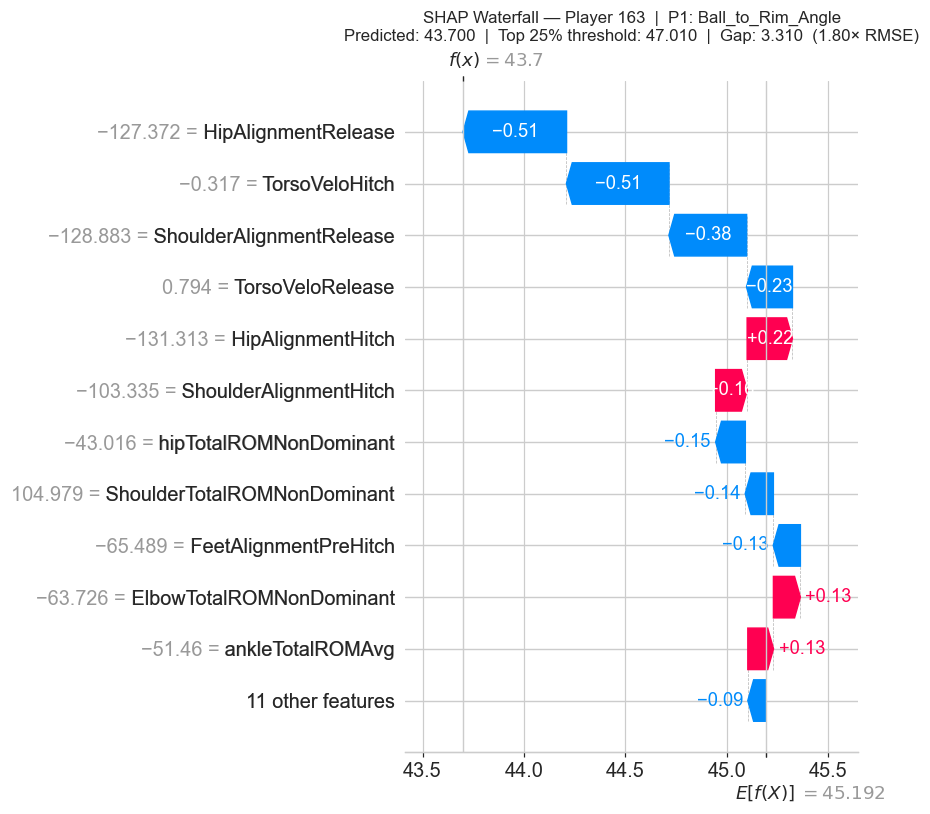

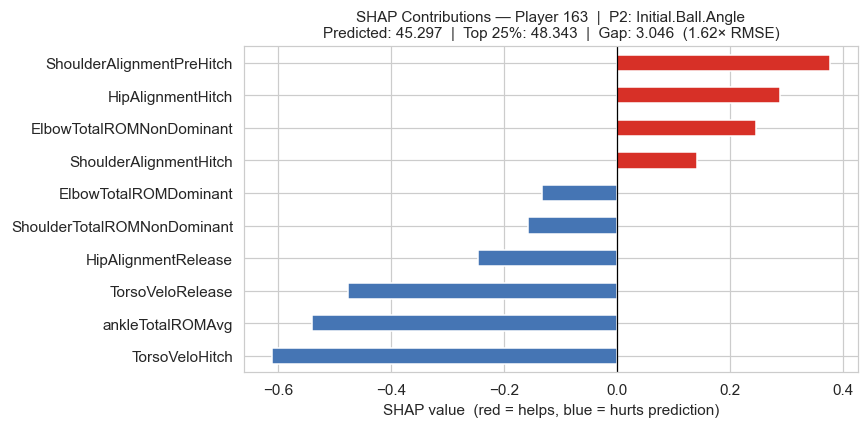

In [50]:
# ── Section 8.3 ── SHAP Analysis — biomechanical drivers per priority metric
#
# For each weak target: compute SHAP values for Player 163's median profile.
# P1 → detailed waterfall plot (full additive breakdown)
# P2+ → compact horizontal bar chart (top 10 features)
# All results stored in shap_per_target for use in the coaching report.

shap_per_target = {}   # target → {sv, rep, X_c, pred}

if not weak_targets:
    print("No priority targets — SHAP analysis skipped.")
else:
    for rank, wt in enumerate(weak_targets, 1):
        target = wt['target']
        X_c    = X_per_target[target]
        exp_t  = explainers_dict[target]
        p_X    = wt['X_player']

        rep    = p_X.median()
        sv     = exp_t.shap_values(rep.values.reshape(1, -1))
        pred_t = float(models[target].predict(rep.values.reshape(1, -1))[0])

        shap_per_target[target] = dict(sv=sv, rep=rep, X_c=X_c, pred=pred_t)

        if rank == 1:
            expl = shap.Explanation(
                values=sv[0],
                base_values=exp_t.expected_value,
                data=rep.values,
                feature_names=list(X_c.columns)
            )
            plt.figure()
            shap.waterfall_plot(expl, max_display=12, show=False)
            plt.title(
                f'SHAP Waterfall — Player 163  |  P1: {target}\n'
                f'Predicted: {wt["pred"]:.3f}  |  Top 25% threshold: {wt["d_p75"]:.3f}'
                f'  |  Gap: {wt["gap"]:.3f}  ({wt["ratio"]:.2f}× RMSE)',
                fontsize=11
            )
            plt.tight_layout()
            plt.show()
            print()

        else:
            sv_series = pd.Series(sv[0], index=X_c.columns)
            top_n     = sv_series.abs().nlargest(10).index
            sv_top    = sv_series[top_n].sort_values()
            colors    = ['#d73027' if v >= 0 else '#4575b4' for v in sv_top]

            fig, ax = plt.subplots(figsize=(8, 4))
            sv_top.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
            ax.axvline(0, color='black', linewidth=0.8)
            ax.set_title(
                f'SHAP Contributions — Player 163  |  P{rank}: {target}\n'
                f'Predicted: {wt["pred"]:.3f}  |  Top 25%: {wt["d_p75"]:.3f}'
                f'  |  Gap: {wt["gap"]:.3f}  ({wt["ratio"]:.2f}× RMSE)',
                fontsize=10
            )
            ax.set_xlabel('SHAP value  (red = helps, blue = hurts prediction)')
            plt.tight_layout()
            plt.show()
            print()

In [51]:
# ── Section 8.4 ── Counterfactual Scenarios — DiCE for top priority targets
#
# DiCE finds the *minimal* biomechanical changes to push predicted ball flight
# into the top-25% range. Three safeguards prevent unreasonable recommendations:
#   1. permitted_range  — constrains each feature to its 5th–95th pctile in training data
#   2. gap > RMSE check — only targets where the gap is statistically real (Section 8.2)
#   3. In-range filter  — extract_cf_recs() (coaching cell) rejects any value still outside bounds

MAX_CF_TARGETS  = 3   # run DiCE for at most this many weak metrics

cf_results          = {}   # target → DiCE result object or None
permitted_range_all = {}   # target → {feat: [lo, hi]}
cf_top_feats        = {}   # target → list of top-SHAP features used

if not weak_targets:
    print("No priority targets — DiCE analysis skipped.")
else:
    for wt in weak_targets[:MAX_CF_TARGETS]:
        target    = wt['target']
        X_clean_t = X_per_target[target]
        y_clean_t = y_per_target[target]
        model_t   = models[target]

        # Top 10 SHAP features for this specific target (from global Section 3 computation)
        sv_all    = shap_values_dict[target]
        X_samp    = shap_samples_dict[target]
        mean_abs  = pd.Series(np.abs(sv_all).mean(axis=0), index=X_samp.columns)
        top_feats = [f for f in mean_abs.nlargest(10).index if f in X_clean_t.columns]
        cf_top_feats[target] = top_feats

        # Per-target permitted range: 5th–95th pctile of each feature in training data.
        # Without this, DiCE's random sampling can propose extreme outlier values
        # (e.g. a 400% increase in torso velocity) that are physically impossible.
        perm_range = {
            feat: [float(X_clean_t[feat].quantile(0.05)), float(X_clean_t[feat].quantile(0.95))]
            for feat in top_feats if feat in X_clean_t.columns
        }
        permitted_range_all[target] = perm_range

        target_min_cf = wt['d_p75']
        target_max_cf = float(y_clean_t.quantile(0.99))

        query_t = wt['X_player'].median().to_frame().T

        print(f"{'─'*64}")
        print(f"DiCE: {target}")
        print(f"  Current: {wt['pred']:.3f}  →  Goal: ≥ {target_min_cf:.3f}"
              f"  (gap: {wt['gap']:.3f},  RMSE: {wt['rmse']:.3f},  ratio: {wt['ratio']:.2f}×)")
        print(f"  Features searched: {len(top_feats)}")
        print(f"  All suggestions constrained to 5th–95th pctile of training data.\n")

        dice_df = (
            pd.concat([X_clean_t, y_clean_t], axis=1)
            .dropna()
            .sample(min(2000, len(X_clean_t)), random_state=42)
            .reset_index(drop=True)
        )

        d_dice   = dice_ml.Data(
            dataframe=dice_df,
            continuous_features=list(X_clean_t.columns),
            outcome_name=target
        )
        m_dice   = dice_ml.Model(model=model_t, backend='sklearn', model_type='regressor')
        exp_dice = dice_ml.Dice(d_dice, m_dice, method='random')

        try:
            cf_t = exp_dice.generate_counterfactuals(
                query_instances=query_t,
                total_CFs=3,
                desired_range=[target_min_cf, target_max_cf],
                features_to_vary=top_feats,
                permitted_range=perm_range,
                random_seed=42
            )
            cf_results[target] = cf_t
            print("Each row shows one possible set of biomechanical adjustments (only changed features shown):\n")
            cf_t.visualize_as_dataframe(show_only_changes=True)
            print()
        except Exception as e:
            print(f"  DiCE could not find valid counterfactuals within the permitted range: {e}")
            print(f"  SHAP-based recommendations will still appear in the coaching report.\n")
            cf_results[target] = None

────────────────────────────────────────────────────────────────
DiCE: Ball_to_Rim_Angle
  Current: 43.700  →  Goal: ≥ 47.010  (gap: 3.310,  RMSE: 1.835,  ratio: 1.80×)
  Features searched: 10
  All suggestions constrained to 5th–95th pctile of training data.



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  9.81it/s]

Each row shows one possible set of biomechanical adjustments (only changed features shown):

Query instance (original outcome : 44.0)


,TorsoVeloPreHitch,TorsoVeloHitch,TorsoVeloRelease,ShoulderAlignmentPreHitch,ShoulderAlignmentHitch,ShoulderAlignmentRelease,HipAlignmentPreHitch,HipAlignmentHitch,HipAlignmentRelease,FeetAlignmentPreHitch,...,KneeTotalROMAvg,hipTotalROMDominant,hipTotalROMNonDominant,hipTotalROMAvg,TorsoTotalROMAvg,ShoulderTotalROMDominant,ShoulderTotalROMNonDominant,ElbowTotalROMDominant,ElbowTotalROMNonDominant,Ball_to_Rim_Angle
0,-0.014,-0.3166,0.7942,-75.2006,-103.3349,-128.882797,-124.505997,-131.313004,-127.371696,-65.489403,...,50.671001,-50.329399,-43.015499,-46.955601,12.6506,120.287697,104.9786,-102.126503,-63.726398,44.0



Diverse Counterfactual set (new outcome: [47.01, 53.03])


,TorsoVeloPreHitch,TorsoVeloHitch,TorsoVeloRelease,ShoulderAlignmentPreHitch,ShoulderAlignmentHitch,ShoulderAlignmentRelease,HipAlignmentPreHitch,HipAlignmentHitch,HipAlignmentRelease,FeetAlignmentPreHitch,...,KneeTotalROMAvg,hipTotalROMDominant,hipTotalROMNonDominant,hipTotalROMAvg,TorsoTotalROMAvg,ShoulderTotalROMDominant,ShoulderTotalROMNonDominant,ElbowTotalROMDominant,ElbowTotalROMNonDominant,Ball_to_Rim_Angle
0,-,0.5975,1.5354,-,-,-,-,-,153.4773,-,...,70.6598,-,-,-,-,-,-,-,-46.3783,47.14037322998047
1,-,0.4443,1.3388,-,-,112.6544,-,-,112.7788,-,...,-,-,-,-,-,146.3575,-,-,-,47.090843200683594
2,-,0.5976,-,-,-,152.964,-,156.106,-,-,...,-,-,-,-,-,154.2298,-,-,-46.3728,47.14362335205078



────────────────────────────────────────────────────────────────
DiCE: Initial.Ball.Angle
  Current: 45.297  →  Goal: ≥ 48.343  (gap: 3.046,  RMSE: 1.878,  ratio: 1.62×)
  Features searched: 10
  All suggestions constrained to 5th–95th pctile of training data.



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 16.53it/s]

Each row shows one possible set of biomechanical adjustments (only changed features shown):

Query instance (original outcome : 45.0)


,TorsoVeloPreHitch,TorsoVeloHitch,TorsoVeloRelease,ShoulderAlignmentPreHitch,ShoulderAlignmentHitch,ShoulderAlignmentRelease,HipAlignmentPreHitch,HipAlignmentHitch,HipAlignmentRelease,FeetAlignmentPreHitch,...,KneeTotalROMAvg,hipTotalROMDominant,hipTotalROMNonDominant,hipTotalROMAvg,TorsoTotalROMAvg,ShoulderTotalROMDominant,ShoulderTotalROMNonDominant,ElbowTotalROMDominant,ElbowTotalROMNonDominant,Initial.Ball.Angle
0,-0.014,-0.3166,0.7942,-75.2006,-103.3349,-128.882797,-124.505997,-131.313004,-127.371696,-65.489403,...,50.671001,-50.329399,-43.015499,-46.955601,12.6506,120.287697,104.9786,-102.126503,-63.726398,45.0



Diverse Counterfactual set (new outcome: [48.3426484525, 59.93276649679997])


,TorsoVeloPreHitch,TorsoVeloHitch,TorsoVeloRelease,ShoulderAlignmentPreHitch,ShoulderAlignmentHitch,ShoulderAlignmentRelease,HipAlignmentPreHitch,HipAlignmentHitch,HipAlignmentRelease,FeetAlignmentPreHitch,...,KneeTotalROMAvg,hipTotalROMDominant,hipTotalROMNonDominant,hipTotalROMAvg,TorsoTotalROMAvg,ShoulderTotalROMDominant,ShoulderTotalROMNonDominant,ElbowTotalROMDominant,ElbowTotalROMNonDominant,Initial.Ball.Angle
0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-96.5394,-,48.79148483276367
1,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,48.75435256958008
2,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,48.88156509399414


In [52]:
# ── Section 8.5 ── Consolidated Coaching Report

def feature_to_plain(name):
    n = name.lower()
    if   'ankle'    in n: body = 'Ankle'
    elif 'knee'     in n: body = 'Knee'
    elif 'hip'      in n: body = 'Hip'
    elif 'shoulder' in n: body = 'Shoulder'
    elif 'elbow'    in n: body = 'Elbow'
    elif 'torso'    in n: body = 'Torso'
    elif 'wrist'    in n: body = 'Wrist'
    else: body = name.split('_')[0].title()

    if   'velo' in n or 'velocity' in n: action = 'velocity'
    elif 'rom'  in n:                    action = 'range of motion'
    elif 'flexion'   in n:               action = 'flexion angle'
    elif 'extension' in n:               action = 'extension'
    elif 'alignment' in n:               action = 'alignment'
    elif 'stance'    in n:               action = 'stance width'
    elif 'gap'       in n:               action = 'gap'
    else:                                action = 'mechanics'

    # 'prehitch' must be checked before 'hitch' (prehitch contains 'hitch' as substring)
    phase = ''
    if   'prehitch' in n: phase = ' pre-hitch'
    elif 'release'  in n: phase = ' at release'
    elif 'hitch'    in n: phase = ' at hitch'

    side = ''
    if   'dominant' in n and 'non' not in n: side = ' (shooting side)'
    elif 'nondominant' in n:                  side = ' (off-hand side)'

    return f"{body} {action}{phase}{side}"


def extract_cf_recs(cf_obj, rep_vals, top_feats, perm_range):
    """Return (feat, orig, cf_val, pct_change) tuples sorted by |pct_change| ascending.

    Sorted smallest-first = minimal-intervention principle: the coaching report
    surfaces the easiest changes first.
    Secondary in-range filter rejects any DiCE value still outside permitted bounds.
    """
    recs = []
    if cf_obj is None:
        return recs
    try:
        best_cf = cf_obj.cf_examples_list[0].final_cfs_df.iloc[0]
        for feat in top_feats:
            if feat not in best_cf.index or feat not in rep_vals.index:
                continue
            orig   = float(rep_vals[feat])
            cf_val = float(best_cf[feat])
            if abs(orig) < 1e-9 or abs(cf_val - orig) < 1e-9:
                continue
            if feat in perm_range:
                lo, hi = perm_range[feat]
                if cf_val < lo or cf_val > hi:
                    continue          # reject any out-of-distribution suggestion
            pct = (cf_val - orig) / abs(orig) * 100
            recs.append((feat, orig, cf_val, pct))
        recs.sort(key=lambda x: abs(x[3]))     # smallest % change first
    except (IndexError, KeyError):
        pass
    return recs


# ── Print the report
W = 68
print("=" * W)
print("  PLAYER 163 — CONSOLIDATED COACHING REPORT")
print("=" * W)
print(f"\n  Make rate        : {make_rate_163:.1%}  (league avg: {make_rate_all:.1%})")
print(f"  Avg miss dist    : {avg_miss_163:.2f} cm  (league avg: {avg_miss_all:.2f} cm)")
print(f"  Shots on record  : {n_shots}")
print()

if not weak_targets:
    print("  Ball flight mechanics look strong — no metric shows a gap larger")
    print("  than model uncertainty. Miss rate may be driven by shot selection,")
    print("  defensive pressure, or contextual factors outside this model.\n")
else:
    for i, wt in enumerate(weak_targets, 1):
        target = wt['target']
        print(f"{'─'*W}")
        print(f"  PRIORITY {i}: {target}")
        print(f"{'─'*W}")
        print(f"  Current predicted   : {wt['pred']:.3f}")
        print(f"  Top 25% threshold   : {wt['d_p75']:.3f}")
        print(f"  Gap                 : {wt['gap']:.3f}  "
              f"({wt['ratio']:.2f}× model RMSE — statistically significant)")
        print(f"  Percentile          : {wt['pctile']:.0f}th\n")

        # SHAP-derived strengths and weaknesses for this target
        if target in shap_per_target:
            sv_t  = shap_per_target[target]['sv']
            X_c_t = shap_per_target[target]['X_c']
            thresh = max(abs(wt['pred']) * 0.01, 0.005)
            sv_ser = pd.Series(sv_t[0], index=X_c_t.columns)
            strgs  = sv_ser[sv_ser >  thresh].sort_values(ascending=False).head(2)
            weaks  = sv_ser[sv_ser < -thresh].sort_values().head(4)

            if not strgs.empty:
                print("  Biomechanical strengths:")
                for feat, val in strgs.items():
                    print(f"    ✓  {feature_to_plain(feat):<46s} [{val:+.3f}]")
                print()

            if not weaks.empty:
                print("  Biomechanical limiters:")
                for feat, val in weaks.items():
                    print(f"    ✗  {feature_to_plain(feat):<46s} [{val:+.3f}]")
                print()

        # Counterfactual-derived specific recommendations
        if target in cf_results:
            rep_vals   = shap_per_target[target]['rep']
            top_feats  = cf_top_feats.get(target, [])
            perm_range = permitted_range_all.get(target, {})
            recs = extract_cf_recs(cf_results[target], rep_vals, top_feats, perm_range)

            if recs:
                print("  Specific recommendations (minimal changes to reach top 25%):")
                print("  All values within the 5th–95th percentile of this dataset.\n")
                for j, (feat, orig, cf_val, pct) in enumerate(recs[:5], 1):
                    direction = 'Increase' if pct > 0 else 'Decrease'
                    sign      = '+' if pct > 0 else ''
                    print(f"    {j}. {direction} {feature_to_plain(feat)}")
                    print(f"         {orig:.3f}  →  {cf_val:.3f}   ({sign}{pct:.1f}%)")
                print()
            else:
                print("  No counterfactual found within permitted bounds.")
                print("  Focus on the biomechanical limiters listed above.\n")
        else:
            print("  (Counterfactual not generated for this metric — see limiters above.)\n")

print("=" * W)
print("\n  CAUSAL CHAIN:")
print("  Biomechanical changes  →  improved ball flight  →  reduced miss distance")
print("  Recommendations derived from SHAP (feature importance) and DiCE (minimal")
print("  intervention counterfactuals). Values reflect this dataset only — consult")
print("  a coach before applying changes in a live practice context.")
print("=" * W)

  PLAYER 163 — CONSOLIDATED COACHING REPORT

  Make rate        : 64.2%  (league avg: 65.4%)
  Avg miss dist    : 5.47 cm  (league avg: 5.18 cm)
  Shots on record  : 3045

────────────────────────────────────────────────────────────────────
  PRIORITY 1: Ball_to_Rim_Angle
────────────────────────────────────────────────────────────────────
  Current predicted   : 43.700
  Top 25% threshold   : 47.010
  Gap                 : 3.310  (1.80× model RMSE — statistically significant)
  Percentile          : 30th

  Biomechanical limiters:
    ✗  Hip alignment at release                       [-0.510]
    ✗  Torso velocity at hitch                        [-0.505]

  Specific recommendations (minimal changes to reach top 25%):
  All values within the 5th–95th percentile of this dataset.

    1. Increase Elbow range of motion (off-hand side)
         -63.726  →  -46.378   (+27.2%)
    2. Increase Knee range of motion
         50.671  →  70.660   (+39.4%)
    3. Increase Torso velocity at release